In [7]:
import os
import random
from utils import *

import pennylane as qml
from pennylane import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 42

# Generating the dataset

We will generate a synthetic dataset, generated by solving the Lorenz system using the Euler method. The Lorenz equations are defined as:

$$
\dot{x} = \sigma (y-x)
$$
$$
\dot{y} = -y -zx + \rho x
$$
$$
\dot{z} = -\beta z +xy
$$

where $(x, y, z)$ are the variables and $(\sigma , \rho , \beta)$ are parameters. 

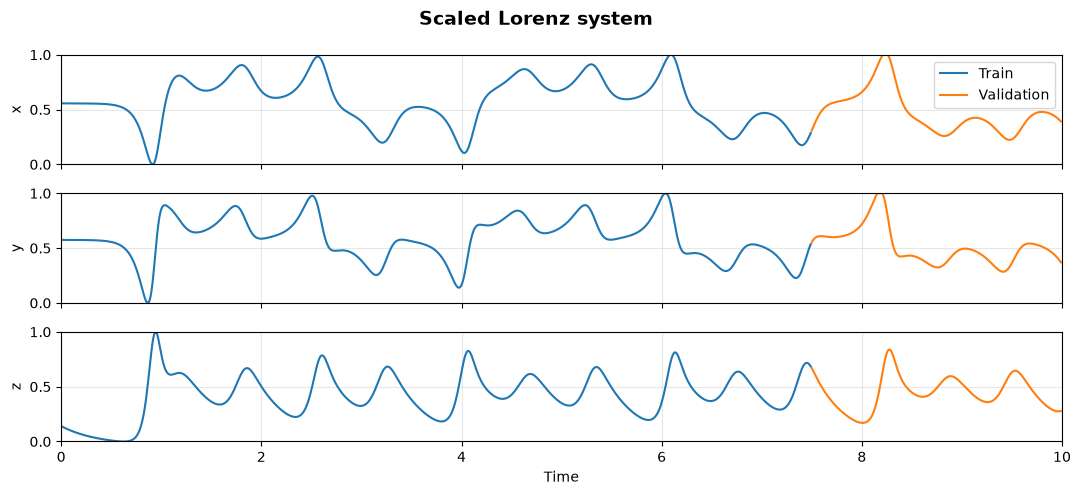

In [8]:
npoints = 1000
h = 0.01
params = [10, 28, 8 / 3]
init_point = [0, -0.01, 9]

dataset = generate_lorenz(
    npoints, 
    h,
    params, 
    init_point
)

# Trin test split
dataset_train, dataset_val = train_test_split(
    dataset,
    test_size=0.25,
    shuffle=False
)
time = np.arange(npoints) * h

time_tr = time[:len(dataset_train)]
time_val = time[len(dataset_train):]

# Scale the data to the range [0, 1]
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(dataset_train)
val_scaled = scaler.transform(dataset_val)
val_scaled = np.clip(val_scaled, 0, 1)

plot_lorenz(train_scaled, val_scaled, time_tr, time_val)

# Independent-chanel VQC

First, we will use and independent VQC per each variable. Each VQC will consist on the aplication of a angle encoding feature map $U_{enc}$ and an ansantz $U_{var}(\theta)$. The chosen architectures are angle encoding via $R_y$ rotations for the feature map, and strongly entangling layers with $R_z, R_y, R_z$ rotations and circular entangling layer for the ansatz. Thus, output per chanel will be given by:

$$
Z_c = \langle 0^{\otimes n}|U_{enc}^\dagger U_{var}^\dagger (\theta) Z_0 U_{var} (\theta) U_{enc} |0^{\otimes n} \rangle 
$$

Finally, by collecting all the chanels we obtain the raw quantum output vector:

$$
Z = [Z_1, ... ,Z_C] \in [-1, 1]^C
$$

which can be rescaled to match the normalized data domain by computing:

$$
\hat{Y} = (Z+1)/2
$$

In [9]:
# Params
batch_size = 128
nreps = 24
window_size = 5
horizon = 1
nqubits = window_size
weights = {"theta": (3 * nqubits * nreps,)} # Strongly entangling layers

# Training hyperparameters
epochs = 50
lr = 5e-4

In [ ]:
# Create the PennyLane QNode 
dev = qml.device("lightning.qubit", wires=nqubits)

def indep_chanel_vqc(inputs, theta):
    angle_encoding(nqubits, inputs)
    VQC_strong(nqubits, theta, nreps)
    return qml.expval(qml.Z(0))

indep_chanel_vqc_node = qml.QNode(
    func=indep_chanel_vqc,
    device=dev,
    interface="torch",
    diff_method="adjoint"
)

# Create the class for the independent VQC model
class IndependentChannelVQC(nn.Module):
    def __init__(self):
        super().__init__()
        self.qlayer = qml.qnn.TorchLayer(indep_chanel_vqc_node, weights)

    def forward(self, x):
        z = self.qlayer(x)
        return (z + 1) / 2

In [11]:
# Create the sequences
x_tr, hor_tr = create_sequences(train_scaled, window_size, horizon)
x_val, hor_val = create_sequences(val_scaled, window_size, horizon)

# Convert to tensor
x_tr = torch.from_numpy(x_tr).double()
hor_tr = torch.from_numpy(hor_tr).double()

x_val = torch.from_numpy(x_val).double()
hor_val = torch.from_numpy(hor_val).double()

# Select each channel independently
val_x = x_val[:, :, 0]  # shape: (n_samples, window_size)
val_y = x_val[:, :, 1]
val_z = x_val[:, :, 2]

val_hor_x = hor_val[:, :, 0]  # shape: (n_samples, horizon)
val_hor_y = hor_val[:, :, 1]
val_hor_z = hor_val[:, :, 2]

# Create the data loaders
train_loader_x = create_channel_loader(x_tr, hor_tr, channel=0, batch_size=batch_size)
train_loader_y = create_channel_loader(x_tr, hor_tr, channel=1, batch_size=batch_size)
train_loader_z = create_channel_loader(x_tr, hor_tr, channel=2, batch_size=batch_size)

In [12]:
### EXECUTION TIME: 105 MINS APROX ###

reset_seeds(SEED)

# Build one independent model for each Lorenz channel
model_x = IndependentChannelVQC()
model_y = IndependentChannelVQC()
model_z = IndependentChannelVQC()

# Use double precision for compatibility with PennyLane
model_x.double()
model_y.double()
model_z.double()

# Mean squared error loss for regression
loss_fn = nn.MSELoss()

# Group loaders, validation datasets and models to train the three channels in the same loop
loaders = (train_loader_x, train_loader_y, train_loader_z)
models = (model_x, model_y, model_z)
val_windows = (val_x, val_y, val_z)
val_horizons = (val_hor_x, val_hor_y, val_hor_z)

histories = []

for loader, model, val_window, val_hor in zip(loaders, models, val_windows, val_horizons):
    print(30 * "#")
    print("Starting training")
    print(30 * "#")

    history = {"Loss": [], "Val loss": []}

    # Save the best model
    best_state = None
    best_val_loss = float("inf")

    # Define optimizer
    opt = torch.optim.Adam(params=model.parameters(), lr=lr)

    for epoch in range(epochs):

        #Training
        model.train()
        epoch_loss = 0
        for xb, yb in loader:
            opt.zero_grad()
            pred = model(xb).squeeze()
            loss = loss_fn(pred, yb.squeeze())
            loss.backward()
            opt.step()
            epoch_loss += loss.item()
        
        # Store average loss for this epoch
        epoch_loss /= len(loader)
        history["Loss"].append(epoch_loss)

        # Evaluation
        model.eval()
        with torch.no_grad():
            val_pred = model(val_window)
            val_loss = loss_fn(val_pred, val_hor.squeeze()).item()

        # Store val loss
        history["Val loss"].append(val_loss)

        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {
                name: params.detach().clone()
                for name, params in model.state_dict().items()
            }

        # Print training progress every 5 epochs
        if epoch == 0 or (epoch + 1) % 5 == 0:
            print(f"Epoch: {epoch + 1} | Loss: {epoch_loss:.4f} | Validation loss: {val_loss:.4f}")

    histories.append(history)
    if best_state is not None:
        model.load_state_dict(best_state)

##############################
Starting training
##############################
Epoch: 1 | Loss: 0.0758 | Validation loss: 0.0357
Epoch: 5 | Loss: 0.0326 | Validation loss: 0.0167
Epoch: 10 | Loss: 0.0113 | Validation loss: 0.0066
Epoch: 15 | Loss: 0.0054 | Validation loss: 0.0038
Epoch: 20 | Loss: 0.0037 | Validation loss: 0.0031
Epoch: 25 | Loss: 0.0030 | Validation loss: 0.0026
Epoch: 30 | Loss: 0.0026 | Validation loss: 0.0023
Epoch: 35 | Loss: 0.0023 | Validation loss: 0.0020
Epoch: 40 | Loss: 0.0021 | Validation loss: 0.0018
Epoch: 45 | Loss: 0.0019 | Validation loss: 0.0016
Epoch: 50 | Loss: 0.0017 | Validation loss: 0.0015
##############################
Starting training
##############################
Epoch: 1 | Loss: 0.0536 | Validation loss: 0.0447
Epoch: 5 | Loss: 0.0276 | Validation loss: 0.0211
Epoch: 10 | Loss: 0.0114 | Validation loss: 0.0078
Epoch: 15 | Loss: 0.0058 | Validation loss: 0.0040
Epoch: 20 | Loss: 0.0038 | Validation loss: 0.0029
Epoch: 25 | Loss: 0.0029 | V

In [20]:
# Save the models
os.makedirs("../models_states", exist_ok=True)

checkpoint = {
    "model_x": model_x.state_dict(),
    "model_y": model_y.state_dict(),
    "model_z": model_z.state_dict(),
    "histories": histories
}

torch.save(checkpoint, "../models_states/independent_channel_vqc.pt")

In [14]:
# # Load the models
# checkpoint = torch.load(
#     "../models_states/independent_channel_vqc.pt",
#     map_location="cpu"
# )

# histories = checkpoint["histories"]

# model_x = IndependentChannelVQC().double()
# model_y = IndependentChannelVQC().double()
# model_z = IndependentChannelVQC().double()

# model_x.load_state_dict(checkpoint["model_x"])
# model_y.load_state_dict(checkpoint["model_y"])
# model_z.load_state_dict(checkpoint["model_z"])

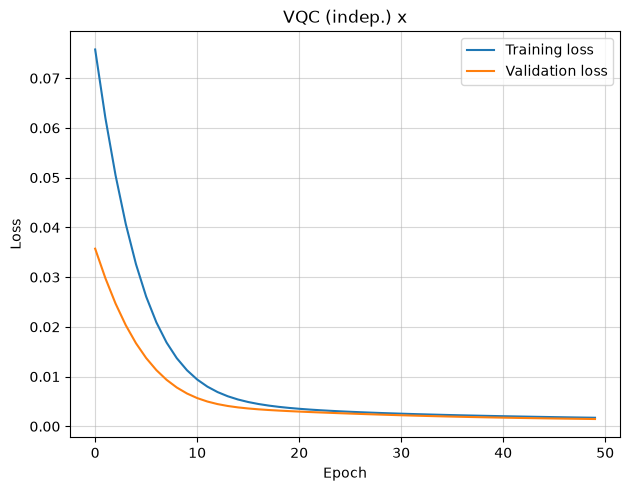

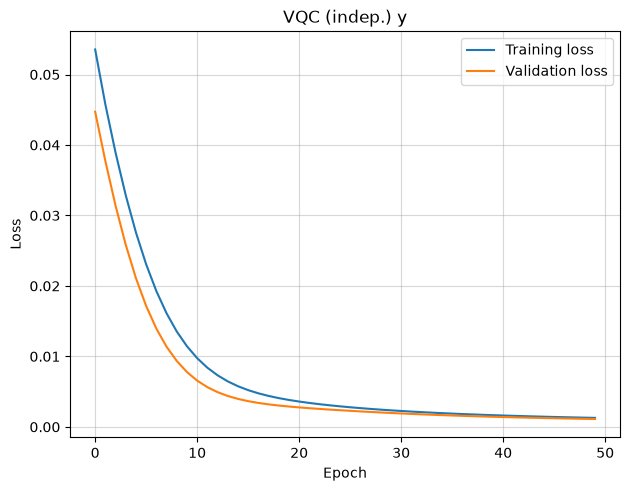

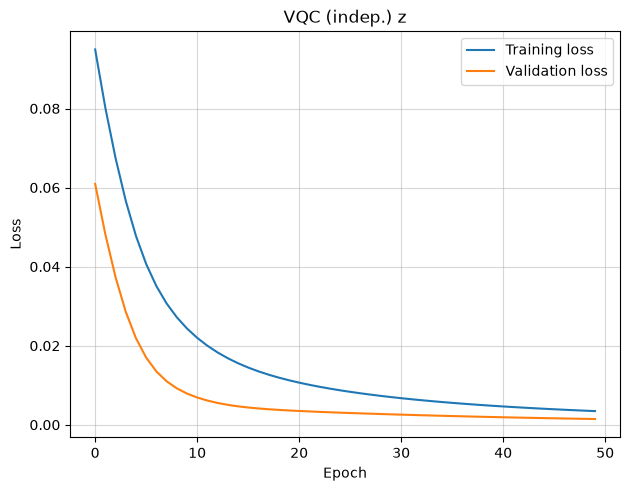

In [15]:
plot_loss(histories[0], "VQC (indep.) x")
plot_loss(histories[1], "VQC (indep.) y")
plot_loss(histories[2], "VQC (indep.) z")

In [16]:
# Evaluation mode
model_x.eval()
model_y.eval()
model_z.eval()

with torch.no_grad():
    pred_x = model_x(val_x).reshape(-1, 1)
    pred_y = model_y(val_y).reshape(-1, 1)
    pred_z = model_z(val_z).reshape(-1, 1)

# Stack predictions and targets: (n_samples, horizon, channels)
pred = torch.stack([pred_x, pred_y, pred_z], dim=2)
target = torch.stack([val_hor_x, val_hor_y, val_hor_z], dim=2)

# =====================
# RMSE
# =====================

squared_error = (pred - target) ** 2

# Per-sample RMSE, averaged over horizon and channels
mean_rmse_list = torch.sqrt(squared_error.mean(dim=(1, 2)))

# Global RMSE
mean_rmse = torch.sqrt(squared_error.mean())

# =====================
# MAE
# =====================

abs_error = torch.abs(pred - target)

# Per-sample MAE, averaged over horizon and channels
mean_mae_list = abs_error.mean(dim=(1, 2))

# Global MAE
mean_mae = abs_error.mean()

# =====================
# MAPE
# =====================

eps = 1e-8

percentage_error = torch.abs((target - pred) / (target + eps))

# Per-sample MAPE, averaged over horizon and channels
mean_mape_list = percentage_error.mean(dim=(1, 2))

# Global MAPE
mean_mape = percentage_error.mean()

print(f"Global RMSE: {mean_rmse:.4f}")
print(f"Global MAE: {mean_mae:.4f}")
print(f"Global MAPE: {mean_mape:.4f}")

Global RMSE: 0.0367
Global MAE: 0.0239
Global MAPE: 0.0481


In [17]:
# Save the results to a CSV file
save_result_csv(
    "../results/lorenz_metrics.csv",
    {
        "forecasting": "short-term",
        "model": "VQC (indep.)",
        "MAPE": mean_mape,
        "MAE": mean_mae,
        "RMSE": mean_rmse,
    },
)

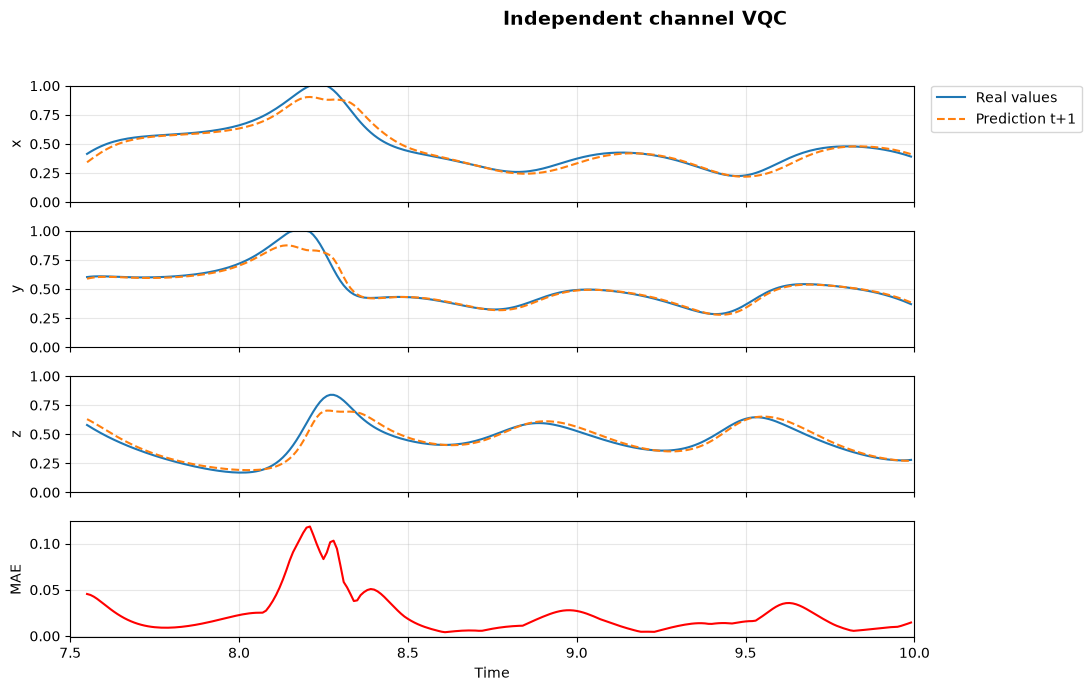

In [18]:
plot_preds_and_error(
    pred_x,
    pred_y,
    pred_z,
    mean_mae_list,
    time_val,
    window_size,
    val_scaled,
    error = "MAE",
    title="Independent channel VQC"
)